# Evolution Training Dashboard

This notebook runs a small evolution job, plots min/P50 loss curves, and writes a Python-native checkpoint.

In [1]:
from pathlib import Path

from self_parking.evolution.config import EvolutionConfig, RetryPolicyConfig, ScenarioConfig, SimulationConfig
from self_parking.evolution.trainer import EvolutionTrainer
from self_parking.io.checkpoint import CheckpointStore
from self_parking.viz.plots import plot_training_history


In [2]:
evolution_config = EvolutionConfig(generation_size=50, generations=15, batch_size=5, seed=42)
simulation_config = SimulationConfig(dt=0.1, episode_seconds=6.0)
scenario_config = ScenarioConfig(start_position='front')
retry_policy = RetryPolicyConfig(enabled=True, retries=1)

trainer = EvolutionTrainer(
    evolution_config=evolution_config,
    simulation_config=simulation_config,
    scenario_config=scenario_config,
    retry_policy=retry_policy,
    show_progress=True,
)
result = trainer.run()
result.best_loss


Generations:   0%|          | 0/15 [00:00<?, ?it/s]

Gen 000 batches:   0%|          | 0/10 [00:00<?, ?it/s]

Gen 001 batches:   0%|          | 0/10 [00:00<?, ?it/s]

Gen 002 batches:   0%|          | 0/10 [00:00<?, ?it/s]

Gen 003 batches:   0%|          | 0/10 [00:00<?, ?it/s]

...

Gen 011 batches:   0%|          | 0/10 [00:00<?, ?it/s]

Gen 012 batches:   0%|          | 0/10 [00:00<?, ?it/s]

Gen 013 batches:   0%|          | 0/10 [00:00<?, ?it/s]

Gen 014 batches:   0%|          | 0/10 [00:00<?, ?it/s]

1.625577697549545

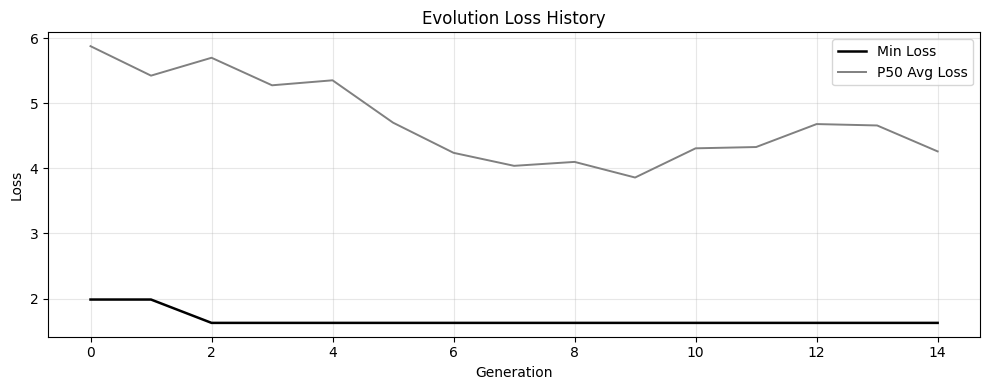

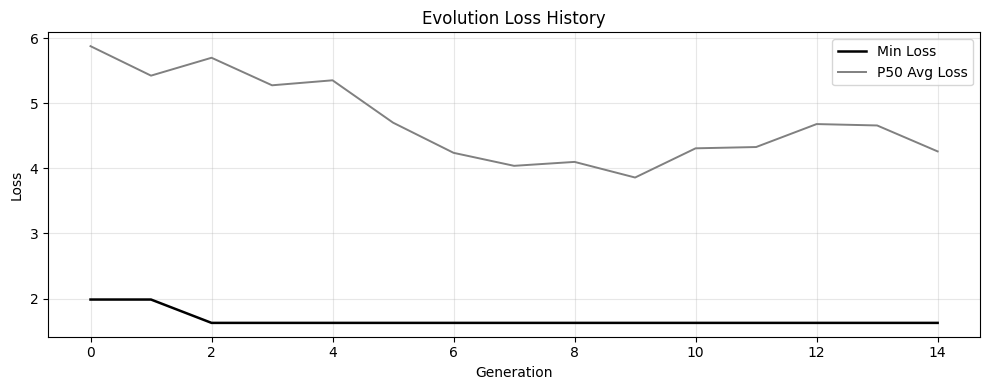

In [3]:
fig, ax = plot_training_history(result.loss_history, result.avg_loss_history)
fig


In [4]:
checkpoint = CheckpointStore.from_training_result(
    training_result=result,
    evolution_config=evolution_config,
    simulation_config=simulation_config,
    scenario_config=scenario_config,
    retry_policy=retry_policy,
)
output = Path('../artifacts/checkpoints/notebook-training.json')
CheckpointStore.save(output, checkpoint)
CheckpointStore.inspect(output)


{'version': 'checkpoint-v1',
 'run_id': '5fc61efa-3530-43e4-be65-222c485f93cd',
 'seed': 42,
 'created_at': '2026-03-15T16:50:14.552303+00:00',
 'generation_index': 14,
 'generation_size': 50,
 'genome_length': 180,
 'best_loss': 1.625577697549545}